Portfolio valuation

Market value weighting

Interest rate scenario analysis

Yield curve shocks

Portfolio P&L attribution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline

In [2]:
from pathlib import Path

ROOT = Path.cwd().parent

In [3]:
treasury = pd.read_csv(ROOT / "data/treasury_yields.csv")

In [4]:
# Create portfolio
maturities = [2,5,7,10,20]
names = ["2Y","5Y","7Y","10Y","20Y"]
notionals = np.array([2,3,1.5,2.5,1]) * 1e6
portfolio = pd.DataFrame({
    "Bond": names, 
    "Maturity": maturities,
    "Face": notionals,
    "Coupon": treasury.iloc[0][names]
})

portfolio.reset_index(drop=True, inplace=True)
portfolio

,Bond,Maturity,Face,Coupon
0,2Y,2,2000000.0,4.11
1,5Y,5,3000000.0,4.17
2,7Y,7,1500000.0,4.28
3,10Y,10,2500000.0,4.41
4,20Y,20,1000000.0,4.87


In [5]:
curve = pd.read_csv(ROOT / "data/continuous_zero_curve.csv")

spot_curve = CubicSpline(
    curve["Years"],
    curve["Spot"]
)


In [6]:
def discount_factor(t):

    r = spot_curve(t) / 100

    return 1 / (1 + r)**t


def cashflows(maturity, coupon_rate, freq = 2, face = 100):

    periods = int(maturity * freq)

    payment = (coupon_rate / 100 * face / freq)

    times = np.arange(1, periods+1) / freq

    cashflows = np.full(
        periods,
        payment
    )

    cashflows[-1] += face

    return times, cashflows

def price_bond(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency,face)

    dfs = discount_factor(times)

    return np.sum(cf * dfs)

In [7]:
portfolio["Unit Price"] = portfolio.apply(
    lambda x:
    price_bond(
        maturity=x["Maturity"],
        coupon_rate=x["Coupon"]
    ),
    axis=1
)

portfolio

,Bond,Maturity,Face,Coupon,Unit Price
0,2Y,2,2000000.0,4.11,99.714968
1,5Y,5,3000000.0,4.17,99.108831
2,7Y,7,1500000.0,4.28,98.685838
3,10Y,10,2500000.0,4.41,98.242813
4,20Y,20,1000000.0,4.87,96.564307


In [8]:
portfolio["Market Value"] = (
    portfolio["Face"]
    * portfolio["Unit Price"]
    / 100
)

portfolio_value = portfolio["Market Value"].sum()

print(f"Portfolio Value: ${portfolio_value:,.2f}")

Portfolio Value: $9,869,565.27


Text(0.5, 1.0, 'Portfolio Allocation')

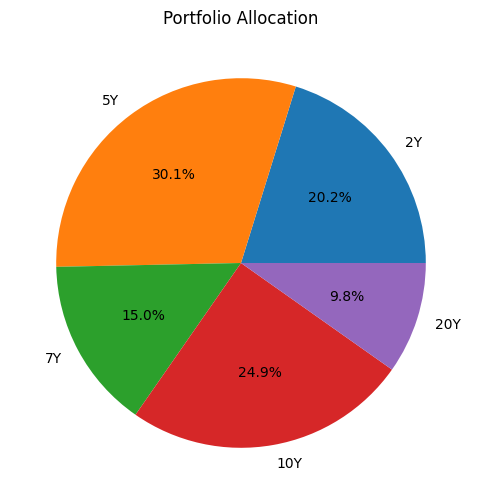

In [9]:
portfolio["Weight"] = (
    portfolio["Market Value"]
    /
    portfolio_value
)

plt.figure(figsize=(6,6))

plt.pie(
    portfolio["Weight"],
    labels=portfolio["Bond"],
    autopct="%1.1f%%"
)

plt.title("Portfolio Allocation")

In [10]:
# Yield curve shock functions

def parallel_shift(curve, shift_bp):

    shocked = curve.copy()

    shocked["Spot"] += shift_bp / 100

    return shocked

def steepener(curve, scale = 1):

    shocked = curve.copy()

    shocked["Spot"] += (shocked["Years"] / shocked["Years"].max()) * scale

    return shocked

def flattener(curve, scale = 1):

    shocked = curve.copy()

    shocked["Spot"] += (1 - shocked["Years"] / shocked["Years"].max()) * scale

    return shocked

def twist(curve, shock = 0.5):

    shocked = curve.copy()

    midpoint = shocked["Years"].median()

    shocked["Spot"] += np.where(
        shocked["Years"] < midpoint,
        shock,
        -shock
    )

    return shocked

In [11]:
# Reprice under stress
def price_portfolio(portfolio, curve):

    spline = CubicSpline(curve["Years"], curve["Spot"])

    def discount_factor(t):

        r = spline(t) / 100

        return 1/(1+r)**t

    values = []

    for _, row in portfolio.iterrows():

        times, cf = cashflows(
            row["Maturity"],
            row["Coupon"]
        )

        price = np.sum(cf * discount_factor(times))

        values.append(price * row["Face"] / 100)

    return np.sum(values)

In [12]:
# Scenario comparison
parallel_up = parallel_shift(curve, 100) # bps
parallel_down = parallel_shift(curve, -100) # bps
steep = steepener(curve)
flat = flattener(curve)
twis = twist(curve)


In [13]:
base_value = price_portfolio(
    portfolio,
    curve
)

pnl_up = price_portfolio(portfolio, parallel_up) - base_value
pnl_down = price_portfolio(portfolio, parallel_down) - base_value
pnl_steepen = price_portfolio(portfolio, steep) - base_value
pnl_flatten = price_portfolio(portfolio, flat) - base_value
pnl_twist = price_portfolio(portfolio, twis) - base_value

results = pd.DataFrame({
    "Scenario": ["Parallel up", "Parallel down", "Steepener", "Flattener", "Twist"],
    "PnL": [pnl_up, pnl_down, pnl_steepen, pnl_flatten, pnl_twist]
})

results


,Scenario,PnL
0,Parallel up,-535722.743997
1,Parallel down,588605.487205
2,Steepener,-161088.248345
3,Flattener,-384495.640610
4,Twist,-191861.531588


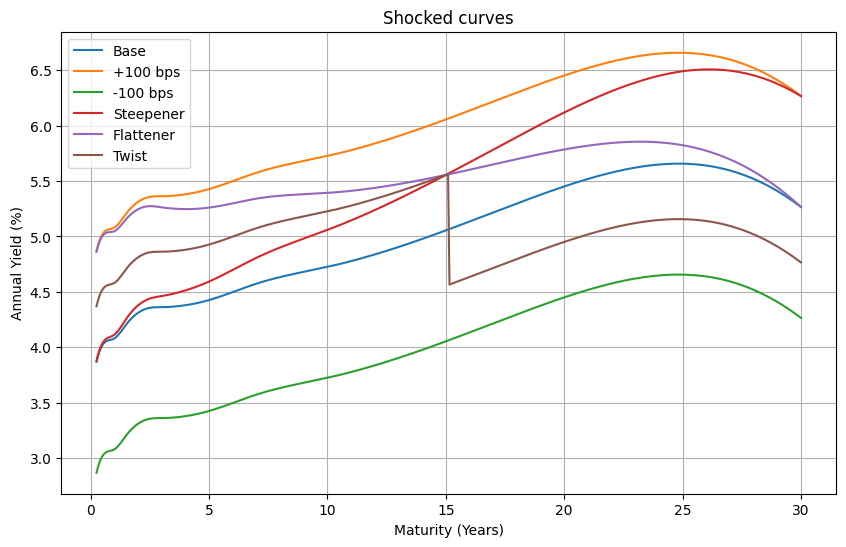

In [14]:
plt.figure(figsize=(10,6))

plt.plot(curve["Years"], curve["Spot"], label="Base")

plt.plot(parallel_up["Years"], parallel_up["Spot"], label="+100 bps")
plt.plot(parallel_down["Years"], parallel_down["Spot"], label="-100 bps")
plt.plot(steep["Years"], steep["Spot"], label="Steepener")
plt.plot(flat["Years"], flat["Spot"], label="Flattener")
plt.plot(twis["Years"], twis["Spot"], label="Twist")


plt.xlabel("Maturity (Years)")
plt.ylabel("Annual Yield (%)")
plt.title("Shocked curves")

plt.legend()
plt.grid()

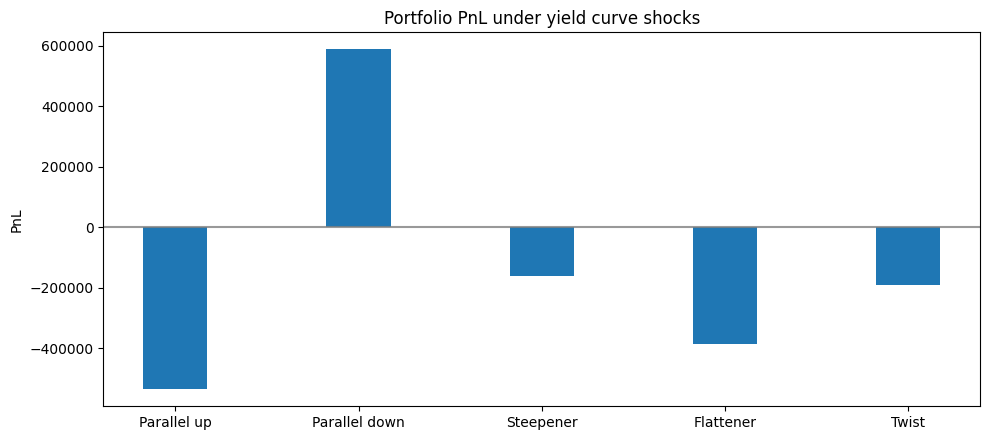

In [18]:
plt.figure(figsize=(10, 4.5))

plt.bar(results["Scenario"], results["PnL"], width=0.35)

plt.axhline(0, color="grey", alpha=0.8)

plt.ylabel("PnL")
#plt.xticks(rotation=20, ha="right")
plt.title("Portfolio PnL under yield curve shocks")

plt.tight_layout()

In [30]:
shocks = np.arange(-200, 250, 50)

pnls = []

for shock in shocks:
    new_curve = parallel_shift(curve, shock)
    pnl = price_portfolio(portfolio, new_curve) - base_value
    pnls.append(pnl * 1e-6)

parallel_shock_df = pd.DataFrame({
    'Shocks': shocks, 
    'PnL': pnls
})

parallel_shock_df.to_csv(ROOT / "data/parallel_shocks.csv")

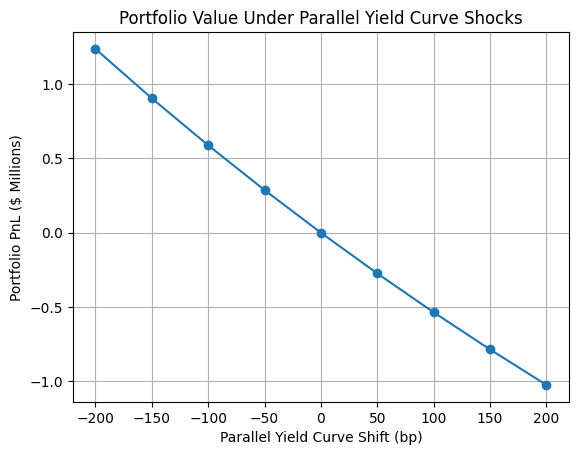

In [ ]:
plt.plot(shocks,pnls,marker="o")

plt.xlabel("Parallel Yield Curve Shift (bp)")
plt.ylabel("Portfolio PnL ($ Millions)")
plt.title("Portfolio Value Under Parallel Yield Curve Shocks")
plt.grid()



In [16]:
portfolio.to_csv(ROOT / "data/sample_portfolio.csv", index = False)